In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [61]:
def getCSV(csv):
    dfl = pd.read_csv(csv_to_get)
    dfl['County'] = dfl['County'].apply(lambda x: x[4:].upper())
    return dfl

csv_to_get = r'C:\Users\Tom\OneDrive\Documents\APROJECTS\persons_on_live_register.csv'
df = getCSV(csv_to_get)
print(df)

               Statistic Label          Month       Age Group         Sex  \
0     Persons on Live Register   2022 January  Under 25 years  Both sexes   
1     Persons on Live Register   2022 January  Under 25 years  Both sexes   
2     Persons on Live Register   2022 January  Under 25 years  Both sexes   
3     Persons on Live Register   2022 January  Under 25 years  Both sexes   
4     Persons on Live Register   2022 January  Under 25 years  Both sexes   
...                        ...            ...             ...         ...   
5827  Persons on Live Register  2023 December        All ages      Female   
5828  Persons on Live Register  2023 December        All ages      Female   
5829  Persons on Live Register  2023 December        All ages      Female   
5830  Persons on Live Register  2023 December        All ages      Female   
5831  Persons on Live Register  2023 December        All ages      Female   

         County    UNIT  VALUE  
0         CLARE  Number    392  
1        

In [62]:
def filterCSV(original_df, time):
    filtered_df = original_df[(original_df['Age Group'] == 'All ages') & (original_df['Sex'] == 'Both sexes') & (original_df['Month'] == time)]
    
    return filtered_df
month = "2022 December"
new_df = filterCSV(df, month)
print(new_df)

               Statistic Label          Month Age Group         Sex  \
2835  Persons on Live Register  2022 December  All ages  Both sexes   
2836  Persons on Live Register  2022 December  All ages  Both sexes   
2837  Persons on Live Register  2022 December  All ages  Both sexes   
2838  Persons on Live Register  2022 December  All ages  Both sexes   
2839  Persons on Live Register  2022 December  All ages  Both sexes   
2840  Persons on Live Register  2022 December  All ages  Both sexes   
2841  Persons on Live Register  2022 December  All ages  Both sexes   
2842  Persons on Live Register  2022 December  All ages  Both sexes   
2843  Persons on Live Register  2022 December  All ages  Both sexes   
2844  Persons on Live Register  2022 December  All ages  Both sexes   
2845  Persons on Live Register  2022 December  All ages  Both sexes   
2846  Persons on Live Register  2022 December  All ages  Both sexes   
2847  Persons on Live Register  2022 December  All ages  Both sexes   
2848  

In [63]:
#import the shapefile data(map: counties of ireland)
counties_shapefile = gpd.read_file(r'C:\Users\Tom\OneDrive\Documents\APROJECTS\Ireland_Counties\Counties___Ungen_2019.shp')

In [64]:
def mergeData():
    merged_data = counties_shapefile.merge(new_df, how='left', left_on='ENGLISH', right_on='County')
    return merged_data
merged_data = mergeData()
print(merged_data)

    OBJECTID   CO_ID    ENGLISH            GAEILGE LOGAINM_ID  \
0          1   50000    DONEGAL       Dún na nGall     100013   
1          2  120000   LIMERICK          Luimneach     100022   
2          3   80000    KILDARE          Cill Dara     100007   
3          4  220000  WATERFORD        Port Láirge     100026   
4          5  260000     DUBLIN  Baile Átha Cliath     100002   
5          6  230000  WESTMEATH          An Iarmhí     100016   
6          7  170000   MONAGHAN         Muineachán     100025   
7          8  250000    WICKLOW      Cill Mhantáin     100008   
8          9   40000       CORK           Corcaigh     100010   
9         10   70000      KERRY            Ciarraí     100005   
10        11  190000  ROSCOMMON         Ros Comáin     100027   
11        12  240000    WEXFORD        Loch Garman     100019   
12        13  130000   LONGFORD        An Longfort     100020   
13        14  160000      MEATH             An Mhí     100024   
14        15   20000     

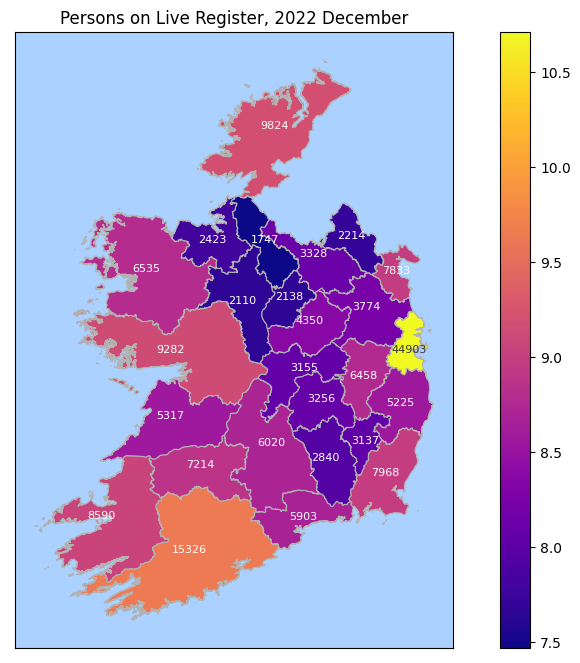

In [66]:
import numpy as np

fig, ax = plt.subplots(1,1, figsize=(12,8))

merged_data['scaled_value'] = round(np.log1p(merged_data['VALUE']), 2)

merged_data.plot(column='scaled_value', cmap='plasma', linewidth=0.8, ax=ax, edgecolor='0.7', legend=True)

text_color = "white"
font_size = 8

for idx, row in merged_data.iterrows():
    persons = row['VALUE']
    if row['County'] == "DUBLIN":
        plt.annotate(text=str(persons), 
                     xy=(row['CENTROID_X'], row['CENTROID_Y']-8000),  # Assuming you have a 'centroid' column with Point geometries
                     color="#333333", 
                     fontsize=font_size,
                     ha='center')
    elif row['County'] == "CORK":
        plt.annotate(text=str(persons), 
                     xy=(row['CENTROID_X']+12000, row['CENTROID_Y']),  # Assuming you have a 'centroid' column with Point geometries
                     color=text_color, 
                     fontsize=font_size,
                     ha='center')
    elif row['County'] == "OFFALY":
        plt.annotate(text=str(persons), 
                     xy=(row['CENTROID_X'], row['CENTROID_Y']+9000),  # Assuming you have a 'centroid' column with Point geometries
                     color=text_color, 
                     fontsize=font_size,
                     ha='center')
    elif row['County'] == "SLIGO":
        plt.annotate(text=str(persons), 
                     xy=(row['CENTROID_X'], row['CENTROID_Y']-6000),  # Assuming you have a 'centroid' column with Point geometries
                     color=text_color, 
                     fontsize=font_size,
                     ha='center')
    elif row['County'] == "ROSCOMMON":
        plt.annotate(text=str(persons), 
                     xy=(row['CENTROID_X']+5000, row['CENTROID_Y']),  # Assuming you have a 'centroid' column with Point geometries
                     color=text_color, 
                     fontsize=font_size,
                     ha='center')
    else:
        plt.annotate(text=str(persons), 
                         xy=(row['CENTROID_X'], row['CENTROID_Y']),  # Assuming you have a 'centroid' column with Point geometries
                         color=text_color, 
                         fontsize=font_size,
                         ha='center')

title_string = "Persons on Live Register, " + month
ax.set_title(title_string)

ax.set_facecolor('#AAD1FF') 

ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('')
ax.set_ylabel('')

#plt.savefig("2022_December_LiveRegister.png")

plt.show()